# 00 · Why diffusion models?

Before a single line of math, the question worth answering: **why does this
strange idea — destroy your data with noise, then train a network to undo it —
work at all, and why did anyone try it?**

This notebook is the *why*. By the end you'll understand the problem diffusion
solves, the ideas it grew from, and the one reframing that made image generation
suddenly tractable. Then we'll watch it happen in 2D.

> **The soul of it, in one line:** *you learn to create by learning to reverse
> destruction — and destruction is easy.*

## The dream, and the wall

Generative modeling has one goal: given a pile of examples — photos, say — learn
to **produce new ones** that could have belonged to the pile. Not copy them;
*invent*.

Formally, you want to model the data distribution $p(x)$ and draw fresh samples
from it. And here is the wall:

- Real images live on a **razor-thin manifold** inside an enormous space. A
  $256\times256$ color image has ~200,000 dimensions, but almost every point in
  that space is meaningless static. The tiny sliver that looks like a real photo
  is fantastically complicated.
- Writing down $p(x)$ means writing down a **normalizing constant**
  $Z = \int \cdots \, dx$ — an integral over that entire space. It is
  **intractable**: you can't compute it, so you can't just evaluate or sample
  $p(x)$ directly.

Every generative method is a different trick for getting around this wall.

## The generative trilemma

By 2019 the field wanted three things from a generator:

1. **High quality** — samples that look real
2. **Diversity** — cover *all* the modes, not just a few (a face generator that
   only makes one face is useless)
3. **Fast sampling** — get a sample without waiting forever

And every method sacrificed one:

| Method | What it gives up |
|---|---|
| **GANs** | *stability & coverage* — stunning, fast samples, but adversarial training is a knife-edge and they quietly **drop modes** |
| **VAEs** | *quality* — stable and principled, but samples come out **blurry** |
| **Autoregressive** (PixelRNN/CNN) | *speed* — great likelihoods, but generate **one pixel at a time**, painfully slowly |
| **Normalizing flows** | *flexibility* — exact likelihood, but the architecture is **shackled** to being invertible |

It felt like a law of nature: **pick two of three.** Diffusion is the method that
broke it.

## The reframe: don't leap — walk

Here is the single idea everything rests on.

What makes generation hard is asking a network to jump from a blank canvas of pure
noise to a coherent image **in one leap** — it has to conjure all the structure at
once. *That* is the impossible part.

So don't leap. **Break the one impossible jump into a thousand trivial steps.**
Each step only has to do something laughably easy: *look at a slightly noisy image
and remove a tiny bit of noise.* Any single step is well within reach of a neural
net. Chain a thousand of them and you travel all the way from pure noise to a
sharp image.

It's the same wisdom behind not solving hard problems in one shot — we take small
steps (gradient descent, iterative refinement). Diffusion applies it to
generation: **turn one intractable problem into a long sequence of easy ones.**

## Two roads to the same idea

What makes diffusion feel *deep* is that it was discovered from two completely
different directions — which turned out to be the same algorithm.

**Road 1 — physics (Sohl-Dickstein et al., 2015).** Watch a drop of ink spread in
water. Going *forward* — structure dissolving into a uniform haze — is trivial to
describe; it's just entropy increasing. The insight: define a forward process that
dissolves *any* dataset into simple Gaussian noise, then train a network to **run
the film backward**. Non-equilibrium thermodynamics even promises that if each
forward step is small, its reverse is also a simple (Gaussian) step — so the
reverse is *learnable*. The paper's title says it all: *Deep Unsupervised Learning
using Nonequilibrium Thermodynamics.*

**Road 2 — score matching (Song & Ermon, 2019).** Forget the intractable $Z$
entirely. Instead of the density, learn only its **gradient** — the *score*
$\nabla_x \log p(x)$, a vector at every point saying "which way is more
data-like." Crucially, that gradient **doesn't depend on $Z$** (the derivative of
a constant is zero). Then generate by walking uphill along the score (Langevin
dynamics). The one quantity that made $p(x)$ intractable simply drops out.

Thermodynamics, score matching, and plain denoising — three roads, **one
algorithm.** When independent ideas converge like that, you've usually found
something real.

## Why it actually works

Pulling the threads together — why this approach succeeds where others struggled:

- **It turns sampling into supervised regression.** The impossible "sample from
  $p(x)$" becomes a stack of easy "predict the noise in this image" problems —
  plain MSE, no adversary, no partition function.
- **The training data is free and infinite.** The forward process needs *no*
  learning — it's just adding noise — and it hands you a perfectly labeled
  (noisy → clean) pair at every noise level, for every image, for free.
- **Small steps stay simple.** Because each step barely perturbs the image, its
  reverse is nearly Gaussian — exactly what a network can represent.
- **It covers modes.** Grounded in likelihood rather than a GAN's adversarial
  game, it spreads attention across the whole distribution instead of collapsing
  to a few favorites.
- **The noise schedule is a built-in curriculum.** High-noise steps fix the coarse
  layout; low-noise steps fill in fine detail. Structure first, texture last.

And it broke the trilemma: **GAN-level quality, VAE-level stability, full
diversity** — trading away only speed, which later tricks (DDIM, distillation —
both coming in this course) largely won back.

In [1]:
import torch
import matplotlib.pyplot as plt

from nanodiffusion.utils import pick_device, set_seed, scatter_2d
from nanodiffusion.data import toy2d
from nanodiffusion.schedules import NoiseSchedule
from nanodiffusion.forward import add_noise

set_seed(0)
device = pick_device()
print("Running on:", device)

Running on: mps


### See it for yourself: the noise forgets where it started

One picture makes the "we must *learn* the reverse" point concrete. Take the whole
dataset, and separately take a **single** data point copied many times. Noise both.
By the final step they are the **same** Gaussian blob — many different starting
points collapse to indistinguishable noise.

So generation can't be "invert $x_T$ back to the one true $x_0$" (that information
is gone) — it must be "**sample a plausible $x_0$**". That is exactly what the rest
of this course learns to do, one small step at a time.

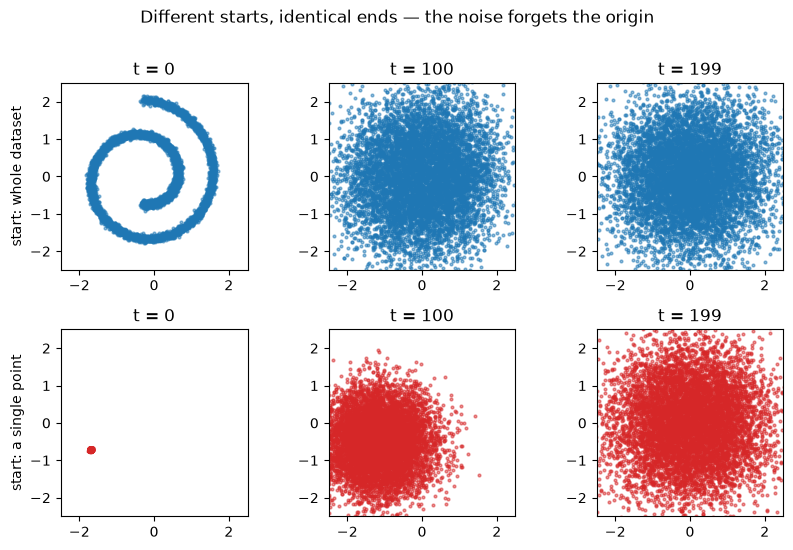

In [2]:
data = toy2d("swiss_roll", 8000)
schedule = NoiseSchedule.make("cosine", timesteps=200)
single = data[0:1].repeat(data.shape[0], 1)     # ONE point, copied 8000 times

ts = [0, 100, 199]
fig, axes = plt.subplots(2, len(ts), figsize=(2.8 * len(ts), 5.4))
for j, t in enumerate(ts):
    tt = torch.full((data.shape[0],), t)
    x_all, _ = add_noise(data, tt, schedule)
    x_one, _ = add_noise(single, tt, schedule)
    scatter_2d(axes[0, j], x_all, f"t = {t}")
    scatter_2d(axes[1, j], x_one, f"t = {t}", color="C3")
axes[0, 0].set_ylabel("start: whole dataset")
axes[1, 0].set_ylabel("start: a single point")
plt.suptitle("Different starts, identical ends — the noise forgets the origin", y=1.01)
plt.tight_layout(); plt.show()

## Now let's watch it — in 2D

Enough philosophy. For the rest of the course we make every piece of the above
concrete, starting in 2D where we can plot the *entire* distribution and literally
watch it dissolve and re-form.

## Our data: a 2D "swiss roll"

Our "dataset" is a cloud of points arranged in a spiral. This stands in for the
true data distribution $q(x_0)$ that we want to learn to sample from.

data shape: (8000, 2)


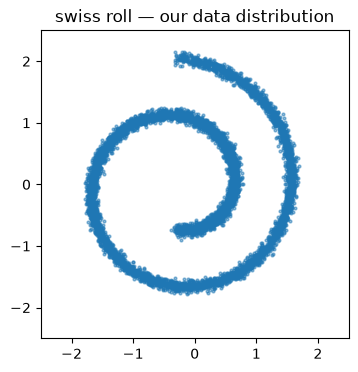

In [3]:
data = toy2d("swiss_roll", n=8000)
print("data shape:", tuple(data.shape))

fig, ax = plt.subplots(figsize=(4, 4))
scatter_2d(ax, data, "swiss roll — our data distribution")
plt.show()

## The forward process: destroy the data

We corrupt the data in small steps. After enough steps, *any* dataset turns into a
featureless blob of Gaussian noise — the spiral is gone. Watch it happen: from
$t=0$ (clean) to $t=T$ (pure noise).

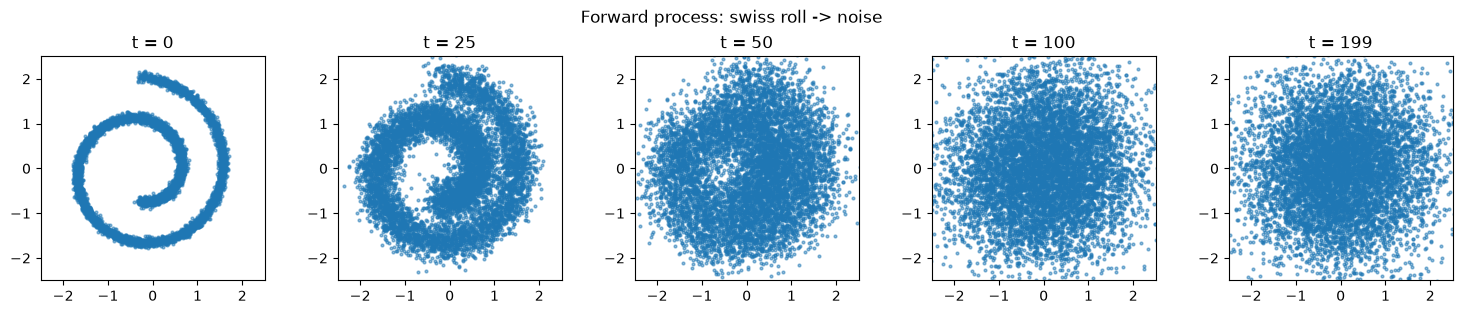

In [4]:
schedule = NoiseSchedule.make("cosine", timesteps=200)

ts = [0, 25, 50, 100, 199]
fig, axes = plt.subplots(1, len(ts), figsize=(3 * len(ts), 3))
for ax, t in zip(axes, ts):
    t_batch = torch.full((data.shape[0],), t, dtype=torch.long)
    x_t, _ = add_noise(data, t_batch, schedule)
    scatter_2d(ax, x_t, f"t = {t}")
plt.suptitle("Forward process: swiss roll -> noise")
plt.tight_layout()
plt.show()

## The reverse process: our goal

Training gives us a network that can undo *one* small noising step. To generate,
we start from the noise on the right and walk **backwards**, step by step, until a
fresh swiss roll appears on the left. We'll build exactly that over the next
notebooks.

## Roadmap

| Notebook | What we build |
|----------|---------------|
| **00 (here)** | Intuition |
| **01** | The forward process, noise schedules, the "nice property" |
| **02** | What the network predicts (ε), and the simple loss |
| **03** | The sampler: noise → data |

Then Part 2 scales this exact machinery up to real images with a U-Net.
Onwards to notebook 01.